# CarbonPulse Finland — Regional Emissions, GDP & Sectoral Carbon Economy
## 19-Region Comparative Analysis

**Inputs (produced by the consolidation scripts):**
- `data/project_data.db` tables: `ghg_emissions_long`, `region_year_summary`, `gdp_by_region_year`, `region_year_with_gdp`

**Requires:** run `01_consolidate_regions.py` (all 19 region files in `region_data/raw/`) and
`02_merge_gdp.py` (`region_data/gdp_raw.xlsx` in place) before running this notebook.
It will run with fewer than 19 regions too — correlation/clustering/map sections just get
richer as you add more files, nothing needs to change in the code.

### Sections
| # | Section |
|---|---------|
| 1 | Load & inspect |
| 2 | Latest-year regional ranking (total & per-capita emissions) |
| 3 | Region similarity — correlation of emission trajectories, clustering |
| 4 | Choropleth map of Finland (colour by emissions) |
| 5 | GDP vs CO₂ — the sectoral carbon economy |
| 6 | Sector breakdown by region (latest year) |
| 7 | Decarbonisation rate ranking (2005 → latest, % change) |


---
## 1 — Load & Inspect

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

DB_PATH = "data/project_data.db"

conn = sqlite3.connect(DB_PATH)
ghg_long   = pd.read_sql("SELECT * FROM ghg_emissions_long", conn)
summary    = pd.read_sql("SELECT * FROM region_year_summary", conn)
try:
    gdp_merged = pd.read_sql("SELECT * FROM region_year_with_gdp", conn)
except Exception:
    gdp_merged = None
    print("region_year_with_gdp not found yet — run 02_merge_gdp.py to unlock Section 5.")
conn.close()

LATEST_YEAR = int(summary["year"].max())
regions = sorted(summary["region"].unique())
print(f"Regions loaded : {len(regions)}  -> {regions}")
print(f"Years          : {summary['year'].min()}–{summary['year'].max()}")
print(f"Latest year    : {LATEST_YEAR}")

if len(regions) < 19:
    print(f"\nNOTE: {len(regions)}/19 regions present. Sections below will run on what's "
          f"available; re-run this notebook after adding the rest to region_data/raw/.")


region_year_with_gdp not found yet — run 02_merge_gdp.py to unlock Section 5.
Regions loaded : 1  -> ['Central Finland']
Years          : 1990–2024
Latest year    : 2024

NOTE: 1/19 regions present. Sections below will run on what's available; re-run this notebook after adding the rest to region_data/raw/.


---
## 2 — Latest-Year Regional Ranking
Total emissions and per-capita emissions, most recent year available.


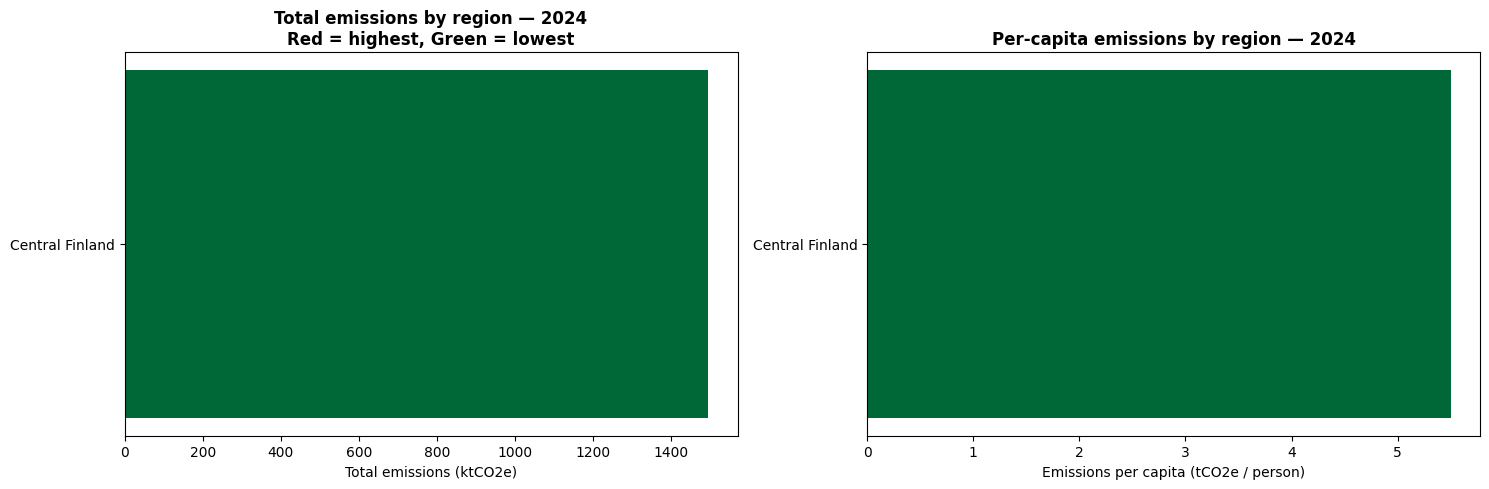

In [2]:
latest = summary[summary["year"] == LATEST_YEAR].sort_values("total_ktco2e", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(regions)*0.35)))

colors_total = cm.RdYlGn_r(mcolors.Normalize()(latest["total_ktco2e"]))
axes[0].barh(latest["region"], latest["total_ktco2e"], color=colors_total)
axes[0].invert_yaxis()
axes[0].set_xlabel("Total emissions (ktCO2e)")
axes[0].set_title(f"Total emissions by region — {LATEST_YEAR}\nRed = highest, Green = lowest",
                   fontweight="bold")

latest_pc = summary[summary["year"] == LATEST_YEAR].sort_values("per_capita_tco2e", ascending=False)
colors_pc = cm.RdYlGn_r(mcolors.Normalize()(latest_pc["per_capita_tco2e"]))
axes[1].barh(latest_pc["region"], latest_pc["per_capita_tco2e"], color=colors_pc)
axes[1].invert_yaxis()
axes[1].set_xlabel("Emissions per capita (tCO2e / person)")
axes[1].set_title(f"Per-capita emissions by region — {LATEST_YEAR}", fontweight="bold")

plt.tight_layout()
plt.savefig("outputs_regional/section2_latest_ranking.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 3 — Region Similarity: Correlation of Emission Trajectories
**Question:** which regions rise and fall together over time — i.e. share the same drivers
(same industry mix, same heating fuel mix, same weather sensitivity)?

We correlate each region's **year-over-year total emissions series** (1990–latest) against
every other region's. High positive correlation = regions decarbonising in the same pattern
(often same dominant sector, e.g. two industrial regions both affected by a paper mill closure
or an electricity-grid decarbonisation that benefits everyone at a similar rate).


In [3]:
pivot_total = summary.pivot_table(index="year", columns="region", values="total_ktco2e")

if pivot_total.shape[1] < 2:
    print("Need at least 2 regions to compute correlation. Add more files and re-run.")
else:
    corr = pivot_total.corr()

    fig, ax = plt.subplots(figsize=(max(8, len(regions)*0.5), max(7, len(regions)*0.45)))
    sns.heatmap(corr, cmap="RdYlGn", center=0.7, vmin=0, vmax=1, annot=(len(regions) <= 12),
                fmt=".2f", linewidths=0.4, ax=ax,
                cbar_kws={"label": "Pearson r (total emissions trajectory)"})
    ax.set_title("Region-to-region correlation of total emissions over time\n"
                 "High r = similar decarbonisation pattern", fontweight="bold")
    plt.tight_layout()
    plt.savefig("outputs_regional/section3_correlation_heatmap.png", dpi=130, bbox_inches="tight")
    plt.show()

    # Hierarchical clustering — group regions with similar trajectories
    dist = 1 - corr
    condensed = squareform(dist.values, checks=False)
    Z = linkage(condensed, method="average")

    fig, ax = plt.subplots(figsize=(10, max(5, len(regions)*0.35)))
    dendrogram(Z, labels=corr.columns.tolist(), orientation="right", ax=ax,
               color_threshold=0.3)
    ax.set_title("Clustering of regions by emissions-trajectory similarity",
                fontweight="bold")
    ax.set_xlabel("Distance (1 - correlation)")
    plt.tight_layout()
    plt.savefig("outputs_regional/section3_dendrogram.png", dpi=130, bbox_inches="tight")
    plt.show()

    print("Most similar region pairs:")
    corr_flat = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
    print(corr_flat.sort_values(ascending=False).head(10))


Need at least 2 regions to compute correlation. Add more files and re-run.


---
## 4 — Choropleth Map of Finland
**Colours regions by total (or per-capita) emissions — red = highest, green = lowest.**

This needs region *boundary geometry*, which isn't in the emissions data. Statistics Finland
publishes it as a free WFS service. This cell tries to fetch it live; if you have no internet
access or `geopandas` isn't installed, it automatically falls back to a labelled ranking chart
(Section 2 already gives you that data — this just tries to also give you a real map).

```
pip install geopandas requests
```


Map fetch failed (No module named 'geopandas'). Falling back to ranked bar chart (see Section 2 for the full-color version) — this is the same information, just without geometry.


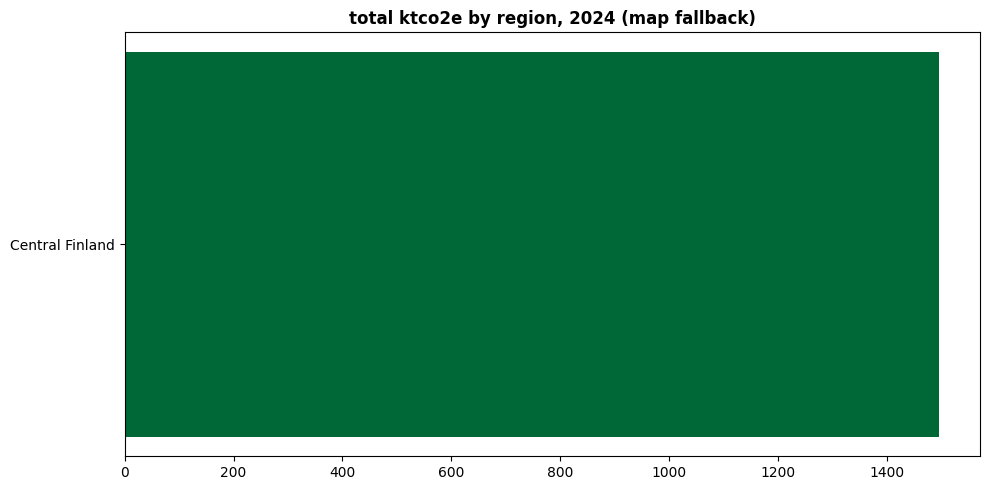

In [4]:
MAP_METRIC = "total_ktco2e"   # or "per_capita_tco2e"

try:
    import geopandas as gpd
    import requests

    WFS_URL = "http://geo.stat.fi/geoserver/tilastointialueet/wfs"
    params = dict(service="WFS", version="2.0.0", request="GetFeature",
                  typeName="tilastointialueet:maakunta4500k", outputFormat="json")
    r = requests.get(WFS_URL, params=params, timeout=20)
    r.raise_for_status()
    geo = gpd.GeoDataFrame.from_features(r.json()["features"], crs="EPSG:3067")

    # geo['name'] holds the Finnish/Swedish/English name trio depending on the layer version;
    # try the common candidates and normalise like the GDP merge step does.
    name_col = next(c for c in ["name", "nimi", "namn"] if c in geo.columns)

    def normalize(name):
        name = str(name).strip()
        trans = str.maketrans("åäöÅÄÖ", "aaoAAO")
        name = name.translate(trans)
        name = name.replace("-", " ")
        return " ".join(name.split()).lower()

    geo["region_key"] = geo[name_col].apply(normalize)
    latest_map = latest.copy()
    latest_map["region_key"] = latest_map["region"].apply(normalize)

    merged_geo = geo.merge(latest_map, on="region_key", how="left")

    fig, ax = plt.subplots(figsize=(9, 12))
    merged_geo.plot(column=MAP_METRIC, cmap="RdYlGn_r", legend=True, ax=ax,
                     edgecolor="white", linewidth=0.5,
                     missing_kwds={"color": "lightgrey", "label": "No data yet"})
    ax.set_title(f"Finland — {MAP_METRIC.replace('_',' ')} by region, {LATEST_YEAR}\n"
                 "Red = highest emissions, Green = lowest", fontweight="bold")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig("outputs_regional/section4_choropleth_map.png", dpi=150, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"Map fetch failed ({e}). Falling back to ranked bar chart (see Section 2 for the "
          f"full-color version) — this is the same information, just without geometry.")
    fig, ax = plt.subplots(figsize=(10, max(5, len(regions)*0.35)))
    colors = cm.RdYlGn_r(mcolors.Normalize()(latest[MAP_METRIC]))
    ax.barh(latest["region"], latest[MAP_METRIC], color=colors)
    ax.invert_yaxis()
    ax.set_title(f"{MAP_METRIC.replace('_',' ')} by region, {LATEST_YEAR} (map fallback)",
                fontweight="bold")
    plt.tight_layout()
    plt.show()


---
## 5 — GDP vs CO₂: The Sectoral Carbon Economy
**Is a region's economy decoupling from carbon** — growing GDP while cutting emissions — or
is growth still carbon-intensive? We look at:
- Scatter: GDP per capita vs CO₂ per capita, latest year, sized/coloured by total emissions
- Time trend: carbon intensity of GDP (tCO2e per million EUR) — is it falling everywhere,
  and which regions are decoupling fastest?


In [5]:
if gdp_merged is None:
    print("Run 02_merge_gdp.py first to populate region_year_with_gdp.")
else:
    latest_gdp = gdp_merged[gdp_merged["year"] == LATEST_YEAR].dropna(subset=["gdp_per_capita_eur"])

    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(latest_gdp["gdp_per_capita_eur"], latest_gdp["per_capita_tco2e"],
                    s=latest_gdp["total_ktco2e"] / latest_gdp["total_ktco2e"].max() * 800 + 40,
                    c=latest_gdp["co2_tonnes_per_million_eur_gdp"], cmap="RdYlGn_r",
                    edgecolor="black", linewidth=0.5, alpha=0.85)
    for _, r in latest_gdp.iterrows():
        ax.annotate(r["region"], (r["gdp_per_capita_eur"], r["per_capita_tco2e"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")
    plt.colorbar(sc, ax=ax, label="Carbon intensity of GDP (tCO2e / million EUR)")
    ax.set_xlabel("GDP per capita (EUR)")
    ax.set_ylabel("CO2 emissions per capita (tCO2e)")
    ax.set_title(f"GDP vs CO2 per capita by region — {LATEST_YEAR}\n"
                 "Bubble size = total regional emissions | Colour = carbon intensity of GDP",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig("outputs_regional/section5_gdp_vs_co2_scatter.png", dpi=130, bbox_inches="tight")
    plt.show()

    # Carbon intensity trend over time, per region
    intensity_pivot = gdp_merged.pivot_table(index="year", columns="region",
                                             values="co2_tonnes_per_million_eur_gdp")
    fig, ax = plt.subplots(figsize=(12, 6))
    intensity_pivot.plot(ax=ax, lw=1.5, alpha=0.85, legend=(len(regions) <= 12))
    ax.set_ylabel("tCO2e per million EUR GDP")
    ax.set_title("Carbon intensity of GDP over time, by region\n"
                 "Falling everywhere = economy-wide decoupling of growth from carbon",
                 fontweight="bold")
    if len(regions) > 12:
        ax.legend(fontsize=7, ncol=2, loc="upper right")
    plt.tight_layout()
    plt.savefig("outputs_regional/section5_carbon_intensity_trend.png", dpi=130, bbox_inches="tight")
    plt.show()


Run 02_merge_gdp.py first to populate region_year_with_gdp.


---
## 6 — Sectoral Carbon Economy: Sector Breakdown by Region
Which sector dominates emissions in each region, in the latest year? A region whose emissions
are mostly `Road transport` + `Agriculture` has a very different decarbonisation path from one
dominated by `Industry` + `District heating`.


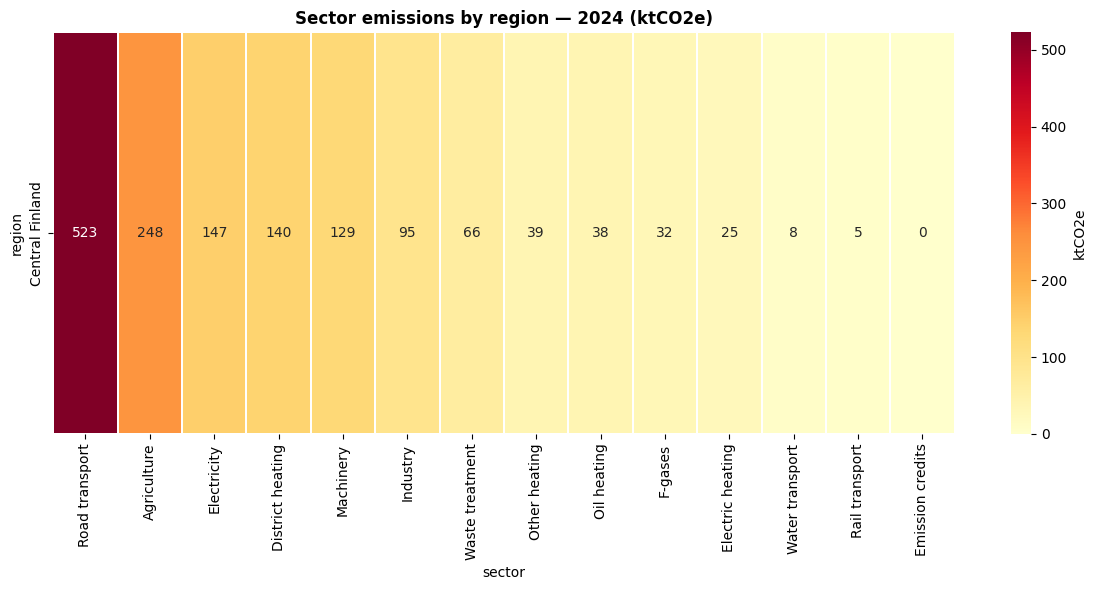

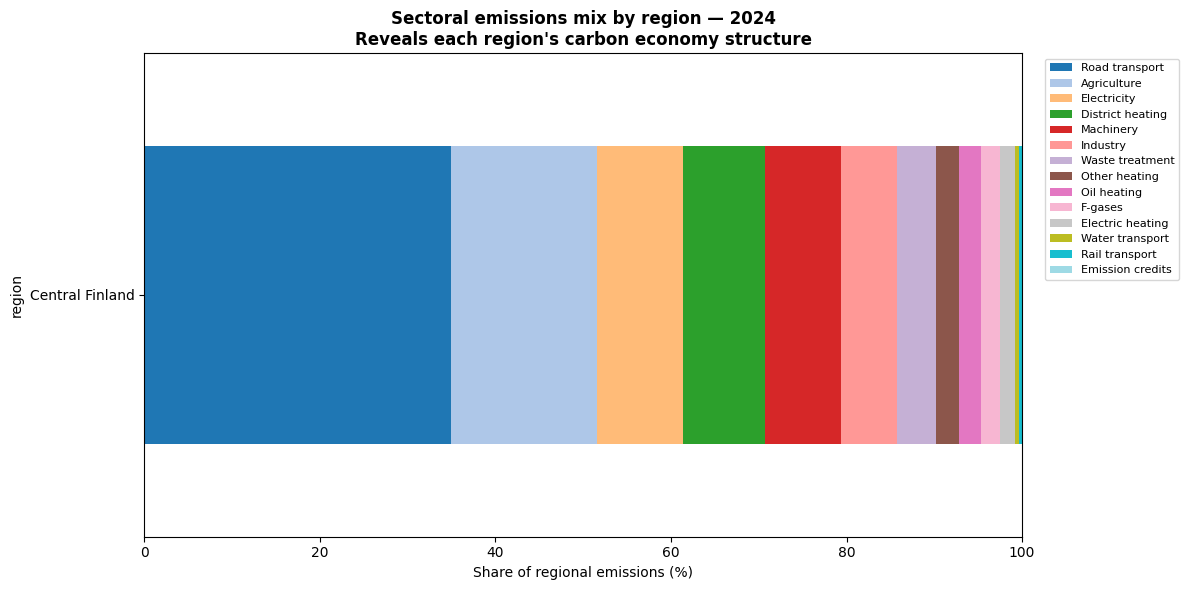

In [6]:
latest_sectors = ghg_long[ghg_long["year"] == LATEST_YEAR]
sector_pivot = latest_sectors.pivot_table(index="region", columns="sector",
                                          values="value_ktco2e", aggfunc="sum").fillna(0)

# Order regions by total, sectors by national total (most important sector first)
sector_pivot = sector_pivot.loc[sector_pivot.sum(axis=1).sort_values(ascending=False).index]
sector_order = sector_pivot.sum(axis=0).sort_values(ascending=False).index
sector_pivot = sector_pivot[sector_order]

fig, ax = plt.subplots(figsize=(12, max(6, len(regions)*0.4)))
sns.heatmap(sector_pivot, cmap="YlOrRd", annot=(len(regions) <= 12), fmt=".0f",
            linewidths=0.3, ax=ax, cbar_kws={"label": "ktCO2e"})
ax.set_title(f"Sector emissions by region — {LATEST_YEAR} (ktCO2e)", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs_regional/section6_sector_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

# Share of each sector within each region (normalised rows) — shows economic structure
sector_share = sector_pivot.div(sector_pivot.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(12, max(6, len(regions)*0.4)))
sector_share.plot(kind="barh", stacked=True, ax=ax, colormap="tab20", width=0.8)
ax.set_xlabel("Share of regional emissions (%)")
ax.set_title(f"Sectoral emissions mix by region — {LATEST_YEAR}\n"
             "Reveals each region's carbon economy structure", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("outputs_regional/section6_sector_share.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 7 — Decarbonisation Rate Ranking (2005 → Latest)
Which regions have cut emissions fastest (%) since 2005, and which have lagged?


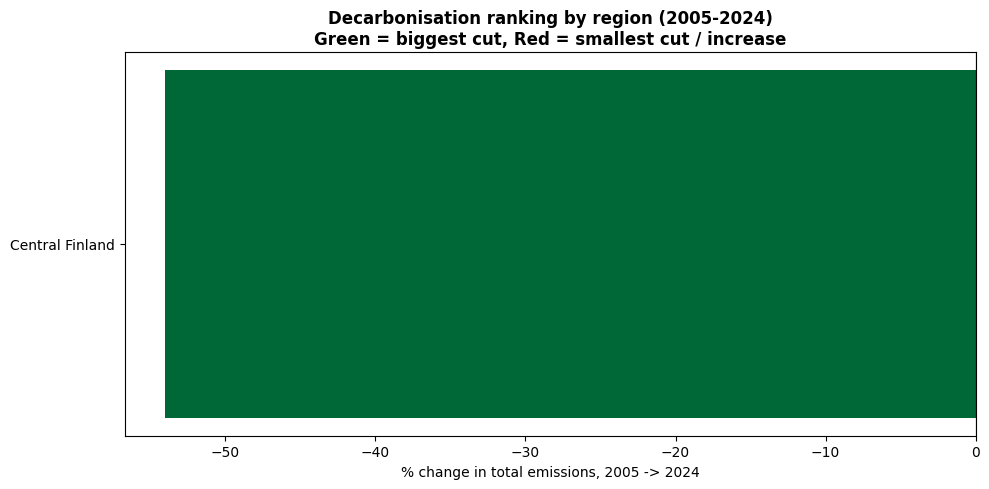

         region   base  latest  pct_change
Central Finland 3252.1  1495.6  -54.011254


In [7]:
base_year = 2005
change = (summary[summary["year"] == base_year][["region","total_ktco2e"]]
          .rename(columns={"total_ktco2e":"base"})
          .merge(summary[summary["year"] == LATEST_YEAR][["region","total_ktco2e"]]
                 .rename(columns={"total_ktco2e":"latest"}), on="region"))
change["pct_change"] = (change["latest"] - change["base"]) / change["base"] * 100
change = change.sort_values("pct_change")

fig, ax = plt.subplots(figsize=(10, max(5, len(regions)*0.35)))
colors = cm.RdYlGn_r(mcolors.Normalize(vmin=change["pct_change"].min(),
                                       vmax=change["pct_change"].max())(change["pct_change"]))
ax.barh(change["region"], change["pct_change"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"% change in total emissions, {base_year} -> {LATEST_YEAR}")
ax.set_title(f"Decarbonisation ranking by region ({base_year}-{LATEST_YEAR})\n"
             "Green = biggest cut, Red = smallest cut / increase", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs_regional/section7_decarbonisation_ranking.png", dpi=130, bbox_inches="tight")
plt.show()

print(change.to_string(index=False))


---
## Summary

Once all 19 region files + the GDP file are in place, this notebook gives your supervisor:
1. A **latest-year emissions leaderboard**, total and per-capita
2. A **similarity/clustering view** of which regions decarbonise alike
3. A **choropleth map** of Finland (or an equivalent ranked chart if geometry can't be fetched)
4. **GDP vs CO₂** — carbon intensity of growth, and whether it's falling (decoupling)
5. A **sector-by-region heatmap** — the "sectoral carbon economy" view your supervisor asked for
6. A **decarbonisation-speed ranking** since 2005

All outputs save to `outputs_regional/*.png` for dropping into a report or slide deck.
